Cauã Benini da Silva (RA )

Universidade Federal de São Carlos (UFSCar)

# Trabalho de Conclusão de Curso (TCC) - Análise Exploratória


# Introdução

O objetivo deste trabalho é prever casos de hipotensão intradiálica em pacientes renais crônicos e posteriormente, adaptar estes modelos para um dashboard interativo a fim de simular sessões de hemodiálise e, com base em atributos demográficos e clínicos, prever se haverá ou não hipotensão durante a sessão.

Este trabalho se baseou no artigo *Predicting the Appearance of Hypotension during Hemodialysis Sessions Using Machine Learning Classifiers* (https://www.mdpi.com/1660-4601/18/5/2364#Abstract).

Abaixo, segue a importação das bibliotecas necessárias para esse desenvolvimento.

# Seleção do Dataset

Utilizou-se o dataset [*Dialysis database: sessions with valid data of clinical parameters*](https://data.mendeley.com/datasets/7kmtsmsgfw/1), disponibilizada pelos autores do artigo citado.

Este conjunto de dados foi coletado no Hospital Príncipe de Asturias (Madrid, Espanha) entre os anos de 2016 e 2019, abrangendo informações clínicas de 758 pacientes submetidos a tratamento de hemodiálise.

O dataset original contém aproximadamente 98.015 medições em sessões de hemodiálise, cada uma re-gistrada com até 22 parâmetros clínicos medidos em seis momentos distintos da sessão (Horas 0 a 5) - de forma com que cada 6 medições subsequentes correspondam a uma sessão de hemodiálise completa -, além de informações demográficas como idade e sexo dos pacientes. Entre
os parâmetros monitorados estão pressão arterial sistólica e diastólica, frequência cardíaca, peso pré e pós-diálise, volume de ultrafiltração, condutividade do banho de hemodiálise,
temperatura corporal, entre outros.

A identificação de episódios de hipotensão intradialítica foi realizada a partir da queda da pressão arterial sistólica maior ou igual a 20 mmHg entre os períodos iniciais e intermediários da sessão. Com base nesse critério, cerca de 25.026 sessões (aproximadamente 26% do total) apresentaram episódios de hipotensão, distribuídos entre 584 pacientes (77% da
amostra).


---

O autor forneceu 11 subcojuntos com múltiplas combinações de atributos válidos (cujas respectivas tuplas não possuem valores nulos ou com ouliers). Nesse caso, foi selecionado o subconjunto 7 da tabela a seguir, tendo em vista que os subconjuntos com mais atributos (8,9,10 e 11) apresentaram inconsistências em relação ao descrito pelo autor do dataset.

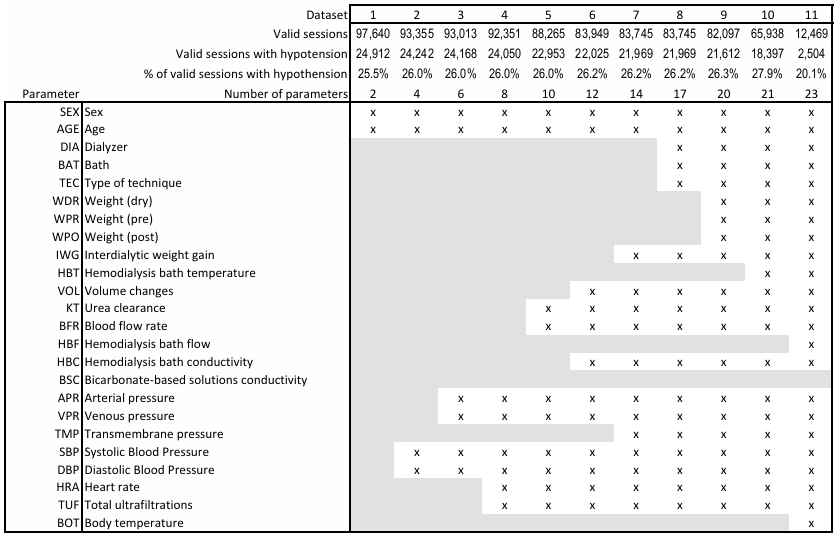

In [ ]:
# Realizar download do Dataset do Drive
!pip install gdown pandas scikit-learn matplotlib xgboost

In [ ]:
import gdown

url = 'https://drive.google.com/uc?id=150jgnqblZ4yIRKvMP8vixDoZE3GPPEqA'
output = 'data/dataset.csv'
gdown.download(url, output, quiet=False)

In [ ]:
# Transformar em Dataframe do Pandas e printar
import pandas as pd

df = pd.read_csv('data/dataset.csv', sep=";", index_col=False)
df